In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Analysing the significance of variant effects in NGN2 and WTC11

### NGN2 Barcode threshhold of 10

In [ ]:
df_NGN2 = pd.read_table('data/results/variants/NGN2_variant_bcalm_bc10_nrep1_mindna1.tsv')
df_NGN2.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id
0,3.200360,0.912453,43.882914,3.969523e-239,1.605672e-234,526.164374,MK:newcore_110751|chr13-80276302+80276571|C-G-241
1,-1.541930,0.944210,-33.963115,9.880952e-184,1.998423e-179,407.904473,MK:tile_37243|chr6-97306567+97306836|ts190-196
2,-1.631066,1.044745,-33.846235,1.180740e-179,1.592031e-175,398.217329,MK:tile_37243|chr6-97306567+97306836|ts198-204
3,-1.477018,0.998698,-32.811974,1.008373e-174,1.019717e-170,387.389314,MK:tile_37243|chr6-97306567+97306836|T-C-197
4,-1.522358,1.015042,-32.054407,2.008151e-168,1.624594e-164,372.999087,MK:tile_37243|chr6-97306567+97306836|A-G-193


#### Creating columns for visualizing variant significance in NGN2

In [ ]:
df_NGN2['minus_log10_adj_p'] = -np.log10(df_NGN2['adj.P.Val'])
df_NGN2['significant'] = df_NGN2['adj.P.Val']<0.05


#### Volcano plot of variant effects in NGN2

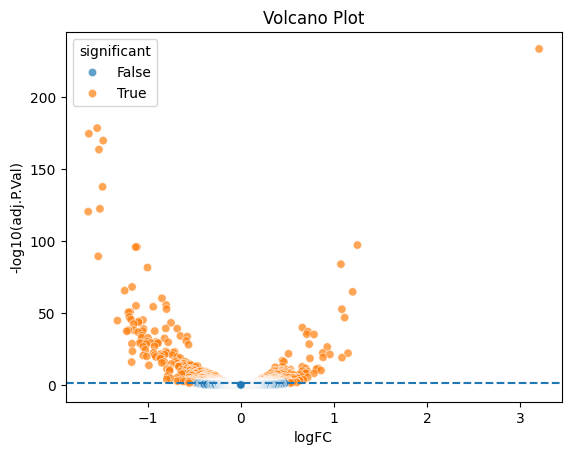

In [ ]:
sns.scatterplot(data = df_NGN2,
                x = 'logFC',
                y = 'minus_log10_adj_p',
                hue = 'significant',
                alpha = 0.7)

plt.axhline(-np.log10(0.05),
            linestyle = '--')

plt.xlabel("logFC")
plt.ylabel("-log10(adj.P.Val)")
plt.title("Volcano Plot")

plt.show()

### WTC11 Barcode threshold 10

In [ ]:
df_WTC11 = pd.read_table('data/results/variants/WTC11_variant_bcalm_bc10_nrep1_mindna1.tsv')
df_WTC11

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id
0,-1.247911,1.077654,-10.154704,5.177989e-24,1.452633e-19,42.101058,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...
1,0.959736,1.525736,9.446673,5.031204e-21,7.057269e-17,36.291394,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...
2,-1.103503,1.164223,-8.820490,1.514795e-18,1.416535e-14,30.307050,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...
3,-0.874146,1.204880,-7.509737,6.885271e-14,4.828984e-10,20.521376,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...
4,-0.772209,1.209609,-7.019622,2.494400e-12,1.399558e-08,17.256347,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...
...,...,...,...,...,...,...,...
28049,-0.001177,0.101267,-0.011742,9.906317e-01,9.987129e-01,-6.208269,cardiac_neuro_cava_random:ALT_FHL1|ENSG0000002...
28050,-0.001346,1.082337,-0.013315,9.893770e-01,9.986491e-01,-6.208369,cardiac_neuro_cava_random:ALT_LINC01626|ENSG00...
28051,0.002050,0.299261,0.020277,9.838232e-01,9.982227e-01,-6.208415,cardiac_neuro_cava_random:ALT_PPP3CA|ENSG00000...
28052,-0.000236,0.162903,-0.002336,9.981366e-01,9.997849e-01,-6.208517,cardiac_neuro_cava_random:ALT_TBL1XR1|ENSG0000...


#### WTC11 Barcode threshold 1

In [ ]:
df_WTC11_bc1 = pd.read_table('data/results/variants_bc_1/WTC11_variant_bcalm_bc10_nrep1_mindna1.tsv')

#### Creating columns for visualizing variant significance in WTC11

In [ ]:
df_WTC11['minus_log_10_adj_p'] = -np.log10(df_WTC11['adj.P.Val'])
df_WTC11['significant'] = df_WTC11['adj.P.Val'] < 0.05

In [ ]:
df_WTC11_bc1['minus_log_10_adj_p'] = -np.log10(df_WTC11_bc1['adj.P.Val'])
df_WTC11_bc1['significant'] = df_WTC11_bc1['adj.P.Val'] < 0.05

#### Volcano plot of variant effects in WTC11 with barcode threshold 10 and 1

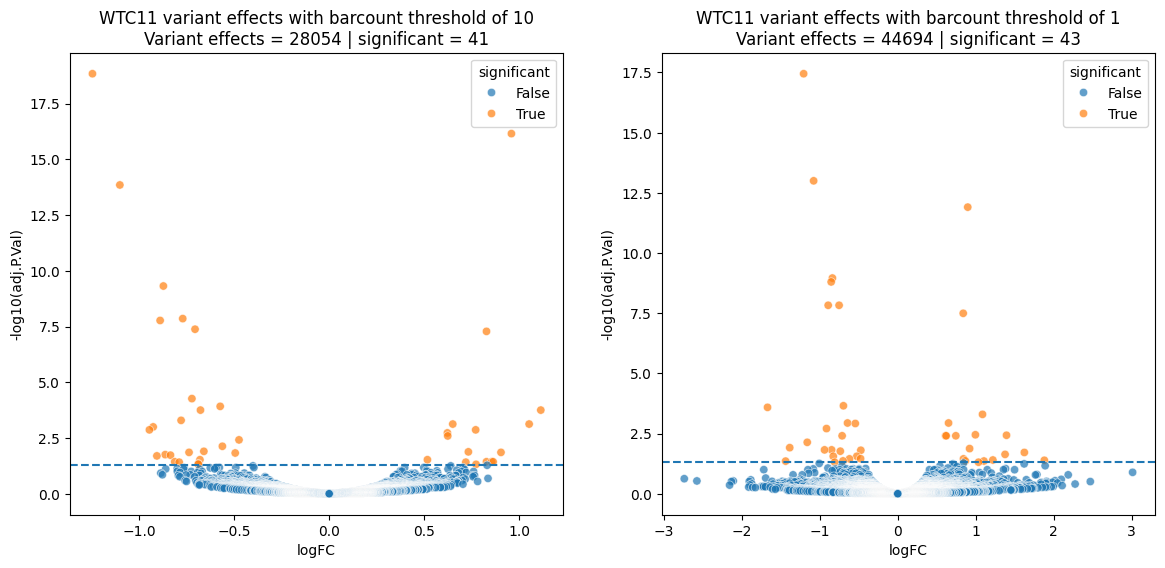

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (14,6))

sns.scatterplot(data = df_WTC11,
                x = 'logFC',
                y = 'minus_log_10_adj_p',
                hue = 'significant',
                alpha = 0.7,
                ax = axes[0] )

axes[0].axhline(-np.log10(0.05),
            linestyle = '--')
axes[0].set_xlabel('logFC')
axes[0].set_ylabel("-log10(adj.P.Val)")
axes[0].set_title(f"WTC11 variant effects with barcount threshold of 10\n"
                  f'Variant effects = {len(df_WTC11)} | significant = {sum(df_WTC11["significant"])}')

sns.scatterplot(data = df_WTC11_bc1,
                x = 'logFC',
                y = 'minus_log_10_adj_p',
                hue = 'significant',
                alpha = 0.7,
                ax = axes[1] )

axes[1].axhline(-np.log10(0.05),
            linestyle = '--')
axes[1].set_xlabel('logFC')
axes[1].set_ylabel("-log10(adj.P.Val)")
axes[1].set_title(f"WTC11 variant effects with barcount threshold of 1\n"
                  f'Variant effects = {len(df_WTC11_bc1)} | significant = {df_WTC11_bc1["significant"].sum()}')

plt.show()

In [ ]:
significant_bc_1 = df_WTC11_bc1[(df_WTC11_bc1['significant'] == True)& (~df_WTC11_bc1['variant_id'].isin(df_WTC11.loc[df_WTC11['significant'], 'variant_id']))]
significant_bc_10 = df_WTC11[(df_WTC11['significant'] == True)& (~df_WTC11['variant_id'].isin(df_WTC11_bc1.loc[df_WTC11_bc1['significant'], 'variant_id']))]

print(f'Size of significant of WTC11 barcode threshold 1 not in WTC11 barcode threshold 10 = {len(significant_bc_1)}\n'
      f'Size of significant of WTC11 barcode threshold 10 not in WTC11 barcode threshold 1 = {len(significant_bc_10)}')

Size of significant of WTC11 barcode threshold 1 not in WTC11 barcode threshold 10 = 11
Size of significant of WTC11 barcode threshold 10 not in WTC11 barcode threshold 1 = 9


In [ ]:
sig10 = set(df_WTC11.loc[df_WTC11["significant"], "variant_id"])
sig1 = set(df_WTC11_bc1.loc[df_WTC11_bc1["significant"], "variant_id"])

overlap = sig10 & sig1

print("bc10 significant:", len(sig10))
print("bc1 significant:", len(sig1))
print("shared significant:", len(overlap))
print("only bc10:", len(sig10 - sig1))
print("only bc1:", len(sig1 - sig10))
print("overlap fraction of bc10:", len(overlap) / len(sig10))
print("overlap fraction of bc1:", len(overlap) / len(sig1))

bc10 significant: 41
bc1 significant: 43
shared significant: 32
only bc10: 9
only bc1: 11
overlap fraction of bc10: 0.7804878048780488
overlap fraction of bc1: 0.7441860465116279


#### Volcano Plot Comparison of Variant Effects in NGN2 and WTC11

Text(0.5, 1.0, 'WTC11 | Size = 28054 | Significant = 41')

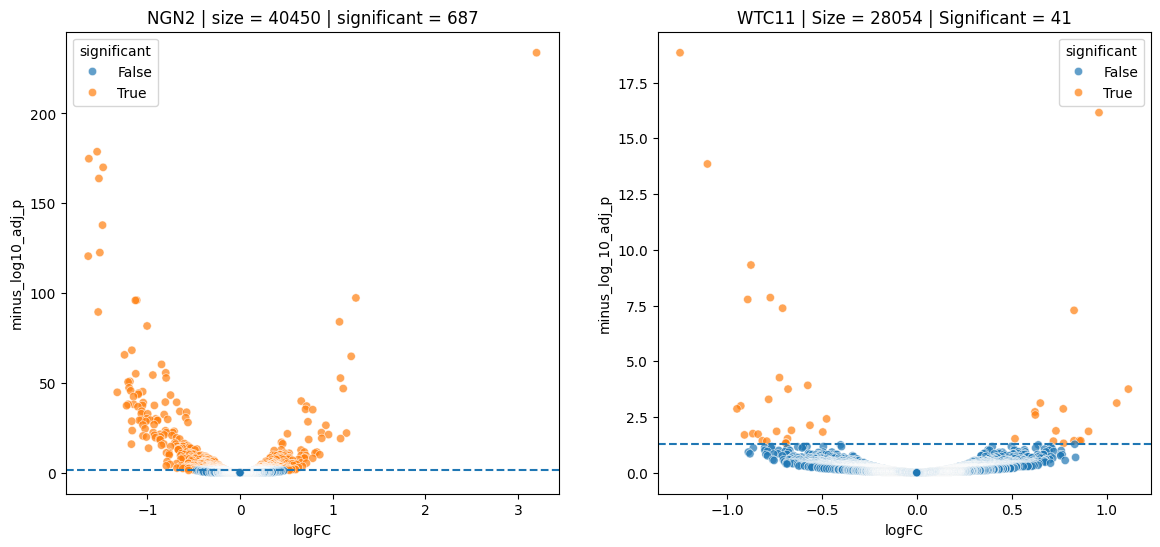

In [ ]:
fig, axes = plt.subplots(1, 2, figsize =(14,6))

sns.scatterplot(data = df_NGN2,
                x = 'logFC',
                y = 'minus_log10_adj_p',
                hue = 'significant',
                alpha = 0.7,
                ax = axes[0])

axes[0].axhline(-np.log10(0.05),
            linestyle = '--')

axes[0].set_title(f'NGN2 | size = {len(df_NGN2)} | significant = {sum(df_NGN2["significant"])}')

sns.scatterplot(data = df_WTC11,
                x = 'logFC',
                y = 'minus_log_10_adj_p',
                hue = 'significant',
                alpha = 0.7,
                ax = axes[1])

axes[1].axhline(-np.log10(0.05),
            linestyle = '--')

axes[1].set_title(f'WTC11 | Size = {len(df_WTC11)} | Significant = {sum(df_WTC11["significant"])}')

In [ ]:
len(df_WTC11), len(df_NGN2)

(28054, 40450)

### Comparing shared and cell-type-specific significant variants in NGN2 and WTC11

#### Percentage of significant variants by cell type

In [ ]:
print(f'The percentage of significant variants in NGN2 Cells is: {round(sum(df_NGN2["adj.P.Val"]<0.05)/len(df_NGN2)*100, 3)}%\n',
      f'NGN2 has {len(df_NGN2)} entries and {sum(df_NGN2["adj.P.Val"]<0.05)} significant variants')
print(f'The percentage of significant variants in WTC11 Cells is: {round(sum(df_WTC11["adj.P.Val"]<0.05)/len(df_WTC11)*100, 3)}%\n',
      f'WTC11 has {len(df_WTC11)} entries and {sum(df_WTC11["adj.P.Val"]<0.05)} significant variants')

The percentage of significant variants in NGN2 Cells is: 1.698%
 NGN2 has 40450 entries and 687 significant variants
The percentage of significant variants in WTC11 Cells is: 0.146%
 WTC11 has 28054 entries and 41 significant variants


#### Overlap of Significant Variants Between NGN2 and WTC11 and Proportion of Shared Significant Variants in NGN2 and WTC11

In [ ]:
WTC11_sig = df_WTC11[df_WTC11['significant']==True]
NGN2_sig = df_NGN2[df_NGN2['significant'] == True]
shared_sig_sum = WTC11_sig['variant_id'].isin(NGN2_sig['variant_id']).sum()
shared_sig_NGN2 = NGN2_sig[NGN2_sig['variant_id'].isin(WTC11_sig['variant_id'])].reset_index(drop =True)
shared_sig_WTC11 = WTC11_sig[WTC11_sig['variant_id'].isin(NGN2_sig['variant_id'])].reset_index(drop =True)


print(f"{shared_sig_sum} significant variants of WTC11 are also in NGN2, that are {round(shared_sig_sum/sum(df_WTC11['significant'] == True)*100,2)}% percent of significants in WTC11")
print(f'{shared_sig_sum} significant variants of NGN2 are also in WTC11, that are {round(shared_sig_sum/sum(df_NGN2["significant"] == True)*100,2)}% percent of significants in NGN2')
print(f'Shared significant variants make up {round(shared_sig_sum/len(df_NGN2)*100, 2)}% in NGN2')
print(f'Shared significant variants make up {round(shared_sig_sum/len(df_WTC11)*100, 2)}% in WTC11')

17 significant variants of WTC11 are also in NGN2, that are 41.46% percent of significants in WTC11
17 significant variants of NGN2 are also in WTC11, that are 2.47% percent of significants in NGN2
Shared significant variants make up 0.04% in NGN2
Shared significant variants make up 0.06% in WTC11


#### Creating a column for easier differentiation between 'significant, not significant, shared significant'

In [ ]:
df_NGN2['sig_category'] = 'not_significant'
df_NGN2.loc[df_NGN2['significant'],'sig_category'] = 'significant'
df_NGN2.loc[df_NGN2['variant_id'].isin(shared_sig_NGN2['variant_id']), 'sig_category'] = 'shared_significant'

df_WTC11['sig_category'] = 'not_significant'
df_WTC11.loc[df_WTC11['significant'],'sig_category'] = 'significant'
df_WTC11.loc[df_WTC11['variant_id'].isin(shared_sig_WTC11['variant_id']), 'sig_category'] = 'shared_significant'

#### Build data set with significant variants but without overlapping significant variants

In [ ]:
noshared_sig_NGN2 = df_NGN2[(df_NGN2['significant'] == True) &
                            (df_NGN2['sig_category'] != 'shared_significant')].reset_index(drop = True)
noshared_sig_WTC11 = df_WTC11[(df_WTC11['significant'] == True) &
                              (df_WTC11['sig_category'] != 'shared_significant')].reset_index(drop = True)

### Volcano plots comparing shared and cell-type-specific significant variants in NGN2 and WTC11

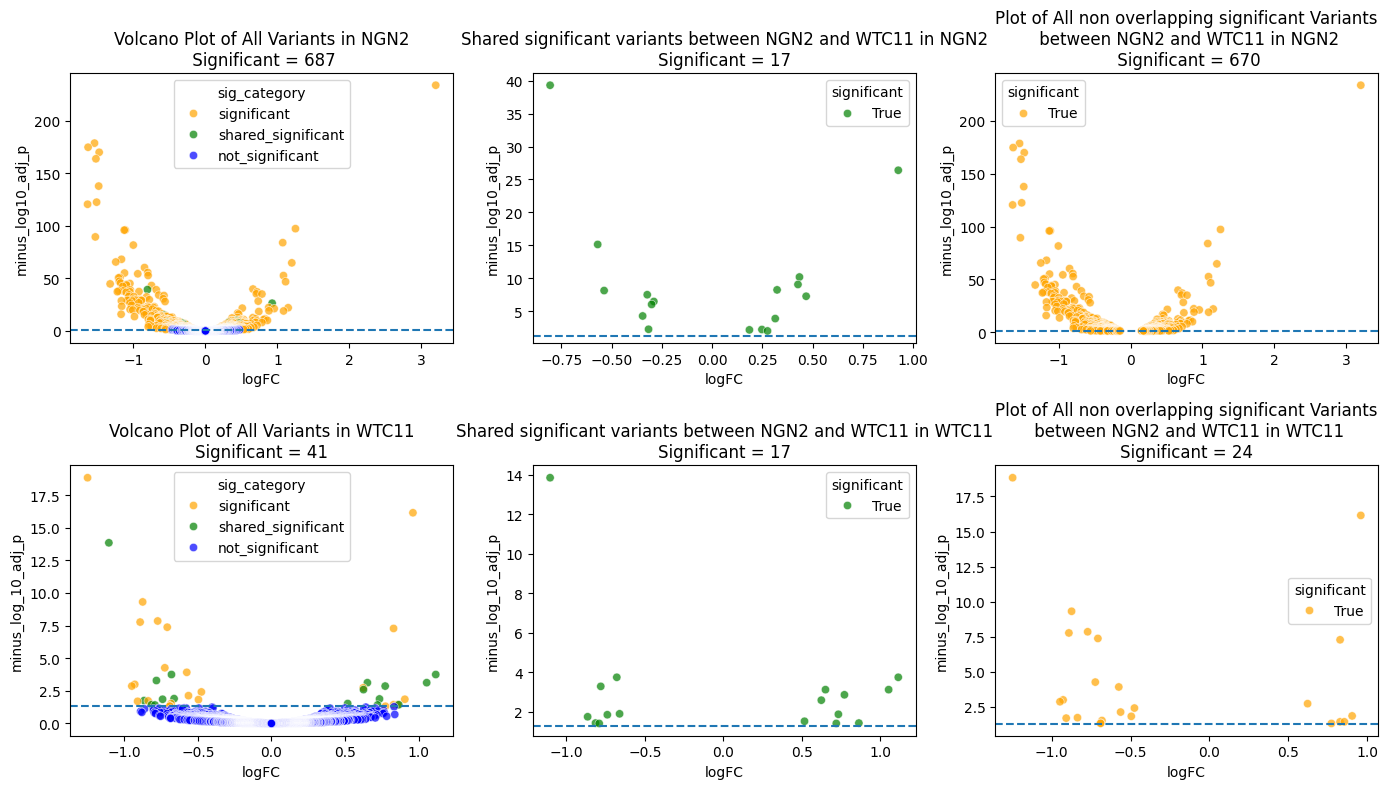

In [ ]:
palette = {
    'significant': 'orange',
    'shared_significant': 'green',
    'not_significant': 'blue'
}

fig , axes = plt.subplots(2,3, figsize = (14,8))

sns.scatterplot(data = df_NGN2,
                x = 'logFC',
                y = 'minus_log10_adj_p',
                hue = 'sig_category',
                palette = palette,
                alpha = 0.7,
                ax = axes[0][0])
axes[0][0].axhline(-np.log10(0.05),
                   linestyle = '--')
axes[0, 0].set_title(f'Volcano Plot of All Variants in NGN2\n Significant = {len(df_NGN2[df_NGN2["significant"] == True])}')

sns.scatterplot(data = shared_sig_NGN2,
                x = 'logFC',
                y = 'minus_log10_adj_p',
                hue = 'significant',
                palette = {True:'green'},
                alpha = 0.7,
                ax = axes[0][1])
axes[0][1].axhline(-np.log10(0.05),
                   linestyle = '--')
axes[0][1].set_title(f'Shared significant variants between NGN2 and WTC11 in NGN2\nSignificant = {len(shared_sig_NGN2[shared_sig_NGN2["significant"] == True])}')

sns.scatterplot(data = noshared_sig_NGN2,
                x = 'logFC',
                y = 'minus_log10_adj_p',
                hue = 'significant',
                palette = {True:'orange'},
                alpha = 0.7,
                ax = axes[0][2])
axes[0][2].axhline(-np.log10(0.05),
                   linestyle = '--')
axes[0][2].set_title(f'Plot of All non overlapping significant Variants\n between NGN2 and WTC11 in NGN2\n Significant = {len(noshared_sig_NGN2[noshared_sig_NGN2["significant"] == True])}')


sns.scatterplot(data = df_WTC11,
                x = 'logFC',
                y = 'minus_log_10_adj_p',
                hue = 'sig_category',
                palette = palette,
                alpha = 0.7,
                ax = axes[1][0])
axes[1][0].axhline(-np.log10(0.05),
                   linestyle = '--')
axes[1][0].set_title(f'Volcano Plot of All Variants in WTC11\nSignificant = {len(df_WTC11[df_WTC11["significant"] == True])}')

sns.scatterplot(data = shared_sig_WTC11,
                x = 'logFC',
                y = 'minus_log_10_adj_p',
                hue = 'significant',
                palette = {True:'green'},
                alpha = 0.7,
                ax = axes[1][1])
axes[1][1].axhline(-np.log10(0.05),
                   linestyle = '--')
axes[1][1].set_title(f'Shared significant variants between NGN2 and WTC11 in WTC11\nSignificant = {len(shared_sig_WTC11[shared_sig_WTC11["significant"] == True])}')

sns.scatterplot(data = noshared_sig_WTC11,
                x = 'logFC',
                y = 'minus_log_10_adj_p',
                hue = 'significant',
                palette = {True:'orange'},
                alpha = 0.7,
                ax = axes[1][2])
axes[1][2].axhline(-np.log10(0.05),
                   linestyle = '--')
axes[1][2].set_title(f'Plot of All non overlapping significant Variants\n between NGN2 and WTC11 in WTC11\nSignificant = {len(noshared_sig_WTC11[noshared_sig_WTC11["significant"] == True])}')

plt.tight_layout()
plt.show()


The percentage of overlapping significant variants in WTC11 is much more higher than in NGN2.  
However, NGN2 has much more significant variants than WTC11 (687 to 41).  
One point is the difference between the number of variants in WTC11 (28054) and NGN2 (40450).  
However, this doesnt explain the over 10 times lesser percentage of significant variants in WTC11 (0.146%) to NGN2 (1.698%).  
The smaller dataset and lesser percentage of significants variants in WTC11 limits the possible overlapping significant variants.  

Question: Why is such a large proportion of the variant data not significant in WTC11, while it is in NGN2?

### Comparison of variant significance across cell types for cardiac_neuro_cava_random label

In [ ]:
WTC11_cardiac_var = df_WTC11[df_WTC11['variant_id'].str.contains('cardiac')]
NGN2_cardiac_var = df_NGN2[df_NGN2['variant_id'].str.contains('cardiac')]

In [ ]:
print(f'WTC11:{len(df_WTC11),len(WTC11_cardiac_var)}\nNGN2: {len(df_NGN2), len(NGN2_cardiac_var)}')

WTC11:(28054, 26974)
NGN2: (40450, 38968)


#### Volcano plot only with the cardiac_neuro_cava_random label variants

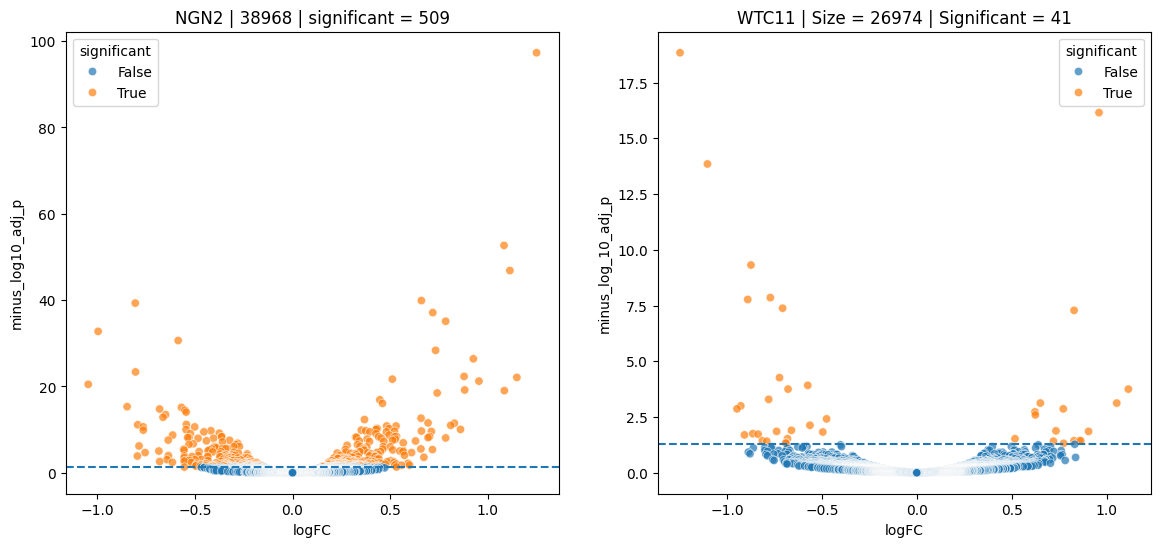

In [ ]:
fig, axes = plt.subplots(1, 2, figsize =(14,6))

sns.scatterplot(data = NGN2_cardiac_var,
                x = 'logFC',
                y = 'minus_log10_adj_p',
                hue = 'significant',
                alpha = 0.7,
                ax = axes[0])

axes[0].axhline(-np.log10(0.05),
            linestyle = '--')

axes[0].set_title(f'NGN2 | {len(NGN2_cardiac_var)} | significant = {sum(NGN2_cardiac_var["significant"])}')

sns.scatterplot(data = WTC11_cardiac_var,
                x = 'logFC',
                y = 'minus_log_10_adj_p',
                hue = 'significant',
                alpha = 0.7,
                ax = axes[1])

axes[1].axhline(-np.log10(0.05),
            linestyle = '--')

axes[1].set_title(f'WTC11 | Size = {len(WTC11_cardiac_var)} | Significant = {sum(WTC11_cardiac_var["significant"])}')


plt.show()


#### The graphic shows that restricting the analysis to variants with the cardiac_neuro_cava_random label substantially reduces the number of significant variants in NGN2 (from 687 to 509), while there is no change in WTC11 (41 significant variants in both cases).

In [ ]:
print(f"The percentage of signifcant variants with the cardiac_neuro_cava_label in NGN2 Cells is: {round(sum(NGN2_cardiac_var['adj.P.Val']<0.05)/len(NGN2_cardiac_var)*100, 3)}%")
print(f"The percentage of signifcant variants with the cardiac_neuro_cava_label in WTC11 Cells is: {round(sum(WTC11_cardiac_var['adj.P.Val']<0.05)/len(WTC11_cardiac_var)*100, 3)}%")

The percentage of signifcant variants with the cardiac_neuro_cava_label in NGN2 Cells is: 1.306%
The percentage of signifcant variants with the cardiac_neuro_cava_label in WTC11 Cells is: 0.152%


# Comparison of Reference and Variant Expression

#### Loading variant map

In [ ]:
df_variants = pd.read_table('data/2509_variant_map_region_based_controls.tsv.gz')

#### Merging NGN2 and WTC11 variant data with outerjoin

In [ ]:
NGN2_WTC11_merge = df_NGN2.merge(right = df_WTC11,
                                 how = 'outer',
                                 on ='variant_id',
                                 suffixes = ['_NGN2', '_WTC11'])

In [ ]:
NGN2_WTC11_subset = NGN2_WTC11_merge[['variant_id','logFC_NGN2','adj.P.Val_NGN2','significant_NGN2','sig_category_NGN2','logFC_WTC11','adj.P.Val_WTC11','significant_WTC11', 'sig_category_WTC11']]

In [ ]:
# 0. Variantendaten für NGN2 und WTC11 cleanen und mergen => Ziel: Tabelle Varianteneffect_NGN2, adjusted_p-value_NGN2, significant_NGN2, Varianteneffect_WTC11, adjusted_p-value_WTC11, significant_WTC11, variant ID
# 1. Varianten daten mergen mit varianten map (varianten ID): Ziel: Reference name und Alternative name mit in der Varianten tabelle
# 1.5 Effekt stäke über die effektstärke der refferenz minus der alt (ALT-REF)
# 2. Referenz und Alternative name nutzen um die element daten an die Variantendaten zu mergen (erst speichern, dann laden)
# 3. Diese daten speichern
# 4. Schaue dir die möglichen einflussfaktoren für die unterschiedliche Anzahl von signifikanten varianten an, Ist die Streuung der element Aktivitäten der Referenzen in NGN2 kleiner als in WTC11?

### Merging the variant map with the variant ids

In [ ]:
NGN2_WTC11_variant_merge = NGN2_WTC11_subset.merge(right = df_variants,
                                                   how = 'left',
                                                   left_on = 'variant_id',
                                                   right_on = 'ID')
NGN2_WTC11_variant_merge.drop(columns='ID', inplace=True)

In [ ]:
element_merge = pd.read_table('data/results/merge_elements/element_merge.tsv.gz')

In [ ]:
element_variant_merge = NGN2_WTC11_variant_merge.merge(right = element_merge,
                                                       how = 'left',
                                                       left_on = 'REF',
                                                       right_on = 'oligo_name')

In [ ]:
element_variant_merge = element_variant_merge.rename(columns={
    'oligo_name': 'oligo_name_REF',

    'dna_count_1_NGN2': 'dna_count_1_REF_NGN2',
    'dna_count_2_NGN2': 'dna_count_2_REF_NGN2',
    'dna_count_3_NGN2': 'dna_count_3_REF_NGN2',

    'rna_count_1_NGN2': 'rna_count_1_REF_NGN2',
    'rna_count_2_NGN2': 'rna_count_2_REF_NGN2',
    'rna_count_3_NGN2': 'rna_count_3_REF_NGN2',

    'unique_barcode_count_NGN2': 'unique_barcode_count_REF_NGN2',
    'effect_size_NGN2': 'effect_size_REF_NGN2',
    'norm_effect_size_NGN2': 'norm_effect_size_REF_NGN2',
    'adj.P.Value_NGN2': 'adj.P.Value_REF_NGN2',

    'dna_count_1_WTC11': 'dna_count_1_REF_WTC11',
    'dna_count_2_WTC11': 'dna_count_2_REF_WTC11',
    'dna_count_3_WTC11': 'dna_count_3_REF_WTC11',

    'rna_count_1_WTC11': 'rna_count_1_REF_WTC11',
    'rna_count_2_WTC11': 'rna_count_2_REF_WTC11',
    'rna_count_3_WTC11': 'rna_count_3_REF_WTC11',

    'unique_barcode_count_WTC11': 'unique_barcode_count_REF_WTC11',
    'effect_size_WTC11': 'effect_size_REF_WTC11',
    'norm_effect_size_WTC11': 'norm_effect_size_REF_WTC11',
    'adj.P.Value_WTC11': 'adj.P.Value_REF_WTC11',

    'label': 'label_REF'
})

In [ ]:
element_variant_merge = element_variant_merge.merge(right = element_merge,
                                                    how = 'left',
                                                    left_on = 'ALT',
                                                    right_on = 'oligo_name')

In [ ]:
element_variant_merge = element_variant_merge.rename(columns={
    'oligo_name': 'oligo_name_ALT',

    'dna_count_1_NGN2': 'dna_count_1_ALT_NGN2',
    'dna_count_2_NGN2': 'dna_count_2_ALT_NGN2',
    'dna_count_3_NGN2': 'dna_count_3_ALT_NGN2',

    'rna_count_1_NGN2': 'rna_count_1_ALT_NGN2',
    'rna_count_2_NGN2': 'rna_count_2_ALT_NGN2',
    'rna_count_3_NGN2': 'rna_count_3_ALT_NGN2',

    'unique_barcode_count_NGN2': 'unique_barcode_count_ALT_NGN2',
    'effect_size_NGN2': 'effect_size_ALT_NGN2',
    'norm_effect_size_NGN2': 'norm_effect_size_ALT_NGN2',
    'adj.P.Value_NGN2': 'adj.P.Value_ALT_NGN2',

    'dna_count_1_WTC11': 'dna_count_1_ALT_WTC11',
    'dna_count_2_WTC11': 'dna_count_2_ALT_WTC11',
    'dna_count_3_WTC11': 'dna_count_3_ALT_WTC11',

    'rna_count_1_WTC11': 'rna_count_1_ALT_WTC11',
    'rna_count_2_WTC11': 'rna_count_2_ALT_WTC11',
    'rna_count_3_WTC11': 'rna_count_3_ALT_WTC11',

    'unique_barcode_count_WTC11': 'unique_barcode_count_ALT_WTC11',
    'effect_size_WTC11': 'effect_size_ALT_WTC11',
    'norm_effect_size_WTC11': 'norm_effect_size_ALT_WTC11',
    'adj.P.Value_WTC11': 'adj.P.Value_ALT_WTC11',

    'label': 'label_ALT'
})

In [ ]:
element_variant_merge.insert(
    loc = 2,
    column = 'variant_effect_NGN2',
    value = element_variant_merge['effect_size_ALT_NGN2']-element_variant_merge['effect_size_REF_NGN2'])
element_variant_merge.insert(
    loc=6,
    column='variant_effect_WTC11',
    value=element_variant_merge['effect_size_ALT_WTC11']
          - element_variant_merge['effect_size_REF_WTC11']
)

In [ ]:
element_variant_merge

,variant_id,logFC_NGN2,variant_effect_NGN2,adj.P.Val_NGN2,significant_NGN2,sig_category_NGN2,variant_effect_WTC11,logFC_WTC11,adj.P.Val_WTC11,significant_WTC11,...,dna_count_2_ALT_WTC11,dna_count_3_ALT_WTC11,rna_count_1_ALT_WTC11,rna_count_2_ALT_WTC11,rna_count_3_ALT_WTC11,unique_barcode_count_ALT_WTC11,label_ALT,effect_size_ALT_WTC11,norm_effect_size_ALT_WTC11,adj.P.Value_ALT_WTC11
0,C_positive_heart_CAD:ALT_rs1037169_rs1037169,-0.010908,NaN,0.987905,False,not_significant,NaN,NaN,NaN,NaN,...,353.0,332.0,671.0,884.0,952.0,53.0,C_positive_heart_CAD,0.094808,0.360180,1.0
1,C_positive_heart_CAD:ALT_rs1051338_rs1051338,-0.055394,-0.000419,0.882584,False,not_significant,-0.043954,-0.099785,0.932064,False,...,643.0,576.0,1167.0,1178.0,1379.0,129.0,C_positive_heart_CAD,-0.035234,0.005209,1.0
2,C_positive_heart_CAD:ALT_rs10750098_rs10750098,0.090207,NaN,0.905374,False,not_significant,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C_positive_heart_CAD:ALT_rs10774625_rs10774625,0.220865,NaN,0.381383,False,not_significant,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C_positive_heart_CAD:ALT_rs10811656_rs10811656,0.060657,NaN,0.900026,False,not_significant,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40445,cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...,0.056570,0.004499,0.900440,False,not_significant,0.583831,0.412295,0.603236,False,...,538.0,535.0,1335.0,1330.0,1588.0,80.0,cardiac_neuro_cava_random,0.281199,0.868967,1.0
40446,cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...,0.026265,-0.022558,0.964544,False,not_significant,0.478543,0.325531,0.713884,False,...,714.0,485.0,1271.0,1368.0,1449.0,86.0,cardiac_neuro_cava_random,0.175911,0.581564,1.0
40447,cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...,0.031585,0.027677,0.920077,False,not_significant,0.218742,0.131339,0.828574,False,...,893.0,678.0,1904.0,2461.0,2535.0,109.0,cardiac_neuro_cava_random,0.462070,1.362681,1.0
40448,cardiac_neuro_cava_random:ALT_ZNF462|ENSG00000...,-0.076358,-0.176300,0.681828,False,not_significant,-0.064091,-0.084470,0.920848,False,...,708.0,658.0,1854.0,1551.0,1888.0,117.0,cardiac_neuro_cava_random,0.179237,0.590643,1.0


In [ ]:
len(element_variant_merge[element_variant_merge['significant_NGN2'] == True]), len(element_variant_merge[element_variant_merge['significant_WTC11'] == True])

(687, 41)

In [ ]:
element_variant_merge.columns.to_list()

['variant_id',
 'logFC_NGN2',
 'variant_effect_NGN2',
 'adj.P.Val_NGN2',
 'significant_NGN2',
 'sig_category_NGN2',
 'variant_effect_WTC11',
 'logFC_WTC11',
 'adj.P.Val_WTC11',
 'significant_WTC11',
 'sig_category_WTC11',
 'REF',
 'ALT',
 'REF_in_metadata',
 'ALT_in_metadata',
 'oligo_name_REF',
 'dna_count_1_REF_NGN2',
 'dna_count_2_REF_NGN2',
 'dna_count_3_REF_NGN2',
 'rna_count_1_REF_NGN2',
 'rna_count_2_REF_NGN2',
 'rna_count_3_REF_NGN2',
 'unique_barcode_count_REF_NGN2',
 'effect_size_REF_NGN2',
 'norm_effect_size_REF_NGN2',
 'adj.P.Value_REF_NGN2',
 'dna_count_1_REF_WTC11',
 'dna_count_2_REF_WTC11',
 'dna_count_3_REF_WTC11',
 'rna_count_1_REF_WTC11',
 'rna_count_2_REF_WTC11',
 'rna_count_3_REF_WTC11',
 'unique_barcode_count_REF_WTC11',
 'label_REF',
 'effect_size_REF_WTC11',
 'norm_effect_size_REF_WTC11',
 'adj.P.Value_REF_WTC11',
 'oligo_name_ALT',
 'dna_count_1_ALT_NGN2',
 'dna_count_2_ALT_NGN2',
 'dna_count_3_ALT_NGN2',
 'rna_count_1_ALT_NGN2',
 'rna_count_2_ALT_NGN2',
 'rna_c